In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import datasets
from datasets import DatasetDict
from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

cache_dir="../cache"
data_dir = Path('data/berkeley_dataset_multi')
TOXIGEN_MAP = {
    'lgbtq': 'sexuality',
    'mental_dis': 'disability',
    'physical_dis': 'disability'
}

2026-01-18 17:13:36.068991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768749216.303561  135411 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768749216.349137  135411 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768749216.747456  135411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768749216.747483  135411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768749216.747486  135411 computation_placer.cc:177] computation placer alr

In [2]:
model = SentenceTransformer('all-mpnet-base-v2')

In [ ]:
data = datasets.load_dataset("toxigen/toxigen-data", cache_dir=cache_dir)
train_df = data['train'].to_pandas()
train_df.columns

In [ ]:
task_dir = 'target=sexuality'
dataset = DatasetDict.load_from_disk(str(data_dir/task_dir))
df_task = dataset['train'].to_pandas()
# Take only actual instances 
df_task = df_task[df_task['value'] == 1]
df_aug = train_df[train_df['target_group'] == 'lgbtq']

In [ ]:
task_labels = ['task'] * df_task.shape[0] + ['new'] * df_aug.shape[0]
embeddings = np.vstack([
    model.encode(df_task['text'].tolist()),
    model.encode(df_aug['text'].tolist())
])

In [ ]:
# # UMAP for dimensionality reduction
# umap = UMAP(n_components=2, random_state=42)
# embeddings_2d_umap = umap.fit_transform(embeddings)

n_samples = embeddings.shape[0]
perplexity = min(30, max(5, n_samples // 4))

# run t-SNE
tsne = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=42, n_iter=1000, learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

# Create results dataframe
results_df = pd.DataFrame({
    'embedding_x': embeddings_2d[:, 0],
    'embedding_y': embeddings_2d[:, 1],
    'task_label': task_labels
})

/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
X = embeddings_2d  # use existing embeddings
n_samples = X.shape[0]
max_k = min(20, int(np.sqrt(n_samples)))  # heuristic upper bound
best_k = 2
best_score = -1.0
scores = {}

for k in tqdm(range(2, max_k + 1)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    labels = kmeans.labels_
    try:
        score = silhouette_score(X, labels)
    except Exception:
        score = -1.0
    scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k

# Fit final KMeans with selected k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
klabels = kmeans_final.labels_

# Add cluster labels to dataframe (in-place)
results_df['cluster'] = klabels

# Quick summary and plot
print(f"selected_k={best_k}, best_silhouette={best_score:.4f}")
print(results_df['cluster'].value_counts())

  0%|          | 0/19 [00:00<?, ?it/s]

selected_k=2, best_silhouette=0.4464
cluster
0    2696
1    2511
Name: count, dtype: int64


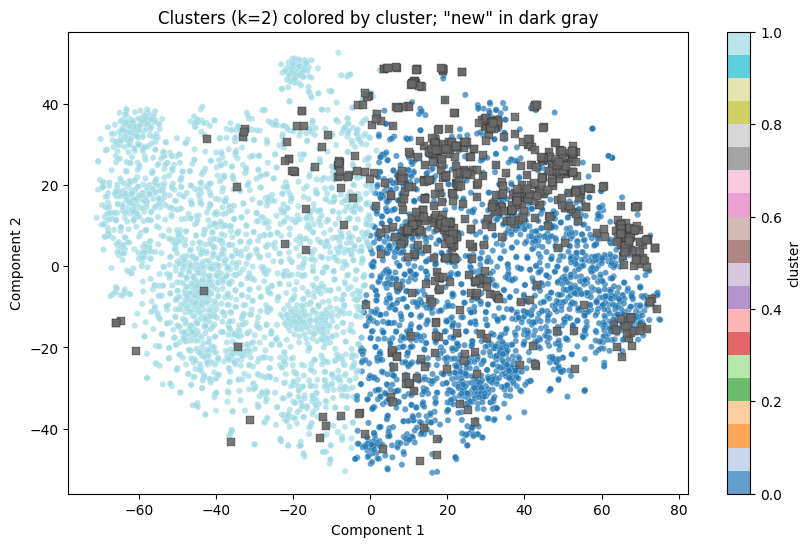

In [ ]:
mask_new = results_df['task_label'] == 'new'
mask_other = ~mask_new

plt.figure(figsize=(10, 6))

# plot non-new points colored by kmeans cluster
sc = plt.scatter(
    results_df.loc[mask_other, 'embedding_x'],
    results_df.loc[mask_other, 'embedding_y'],
    c=results_df.loc[mask_other, 'cluster'],
    cmap='tab20',
    s=20,
    alpha=0.7,
    marker='o',
    edgecolors='w',
    linewidths=0.2
)

# plot 'new' points with dark gray color and different marker
plt.scatter(
    results_df.loc[mask_new, 'embedding_x'],
    results_df.loc[mask_new, 'embedding_y'],
    c='dimgray',
    s=30,
    alpha=0.9,
    marker='s',
    edgecolors='k',
    linewidths=0.2,
    label='new'
)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title(f'Clusters (k={best_k}) colored by cluster; "new" in dark gray')
plt.colorbar(sc, label='cluster')
plt.show()

In [ ]:
new_counts = pd.DataFrame({
    'cluster': results_df['cluster'],
    'is_new': results_df['task_label'] == 'new'
}).value_counts().reset_index().rename(columns={'count': 'count_new'})
new_counts = new_counts[new_counts['is_new'] == True]
item_counts = results_df['cluster'].value_counts().reset_index()\
    .rename(columns={'count': 'count_total'})
new_counts = new_counts.merge(item_counts, on='cluster')
new_counts = new_counts.assign(new_ratio = new_counts['count_new']/new_counts['count_total'])
new_counts

,cluster,is_new,count_new,count_total,new_ratio
0,0,True,653,2696,0.242211
1,1,True,61,2511,0.024293
